In [1]:
!pip -q install -U \
unsloth \
datasets \
sentence-transformers \
bert-score \
evaluate \
scikit-learn \
pandas \
matplotlib \
tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8

In [2]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import re
import json
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset

from unsloth import FastLanguageModel
from unsloth.chat_templates import (train_on_responses_only,)

from trl import SFTTrainer, SFTConfig
from peft import PeftModel
from sentence_transformers import (SentenceTransformer,util)

from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")


print("=" * 70)

print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU   :", torch.cuda.get_device_name(0))
    print("CUDA  :", torch.version.cuda)
    print("Memory:",round(torch.cuda.get_device_properties(0).total_memory / 1024**3,2,),"GB",)

print("=" * 70)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
CUDA  : 12.8
Memory: 14.56 GB


In [3]:
# Model

BASE_MODEL = "unsloth/DeepSeek-R1-Distill-Llama-8B"
MAX_SEQ_LENGTH=6144
LOAD_IN_4BIT=True
DTYPE=None

# Dataset

DATASET_PATH="/kaggle/input/datasets/adityammantri/cybersecurity-red-team-and-blue-team-sft-dataset/train_red.jsonl"

TRAIN_SPLIT=0.80
VAL_SPLIT=0.10
TEST_SPLIT=0.10

# LoRA-Hyperparameters

LORA_RANK=32
LORA_ALPHA=64
LORA_DROPOUT=0.05

TARGET_MODULES = [

    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",

    "gate_proj",
    "up_proj",
    "down_proj",]

# Training

BATCH_SIZE=1
GRAD_ACCUM=16
EPOCHS=5
LEARNING_RATE=2e-4
WEIGHT_DECAY=0.01
WARMUP_RATIO=0.05
LOGGING_STEPS=10
OUTPUT_DIR="./outputs"
SAVE_STRATEGY="epoch"
EVAL_STRATEGY="epoch"
SAVE_TOTAL_LIMIT = 5

# Generation

MAX_NEW_TOKENS=1024
TEMPERATURE=0.1
TOP_P=0.95
DO_SAMPLE = False

# Misc

SEED = 42
print("=" * 70)
print("Configuration Loaded")
print("=" * 70)
print(f"Model              : {BASE_MODEL}")
print(f"Context Length     : {MAX_SEQ_LENGTH}")
print(f"Epochs             : {EPOCHS}")
print(f"Batch Size         : {BATCH_SIZE}")
print(f"Gradient Accum     : {GRAD_ACCUM}")
print(f"Learning Rate      : {LEARNING_RATE}")
print("=" * 70)

Configuration Loaded
Model              : unsloth/DeepSeek-R1-Distill-Llama-8B
Context Length     : 6144
Epochs             : 5
Batch Size         : 1
Gradient Accum     : 16
Learning Rate      : 0.0002


In [4]:
# ============================================================
# Load Base Model
# ============================================================

model, tokenizer=FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
    device_map={"": torch.cuda.current_device()},)

model.config.use_cache=False

print("=" * 70)
print("Base Model Loaded Successfully")
print("=" * 70)

print(f"Model          : {BASE_MODEL}")
print(f"Tokenizer       : {tokenizer.name_or_path}")
print(f"Vocabulary Size : {tokenizer.vocab_size}")
print(f"Max Context     : {MAX_SEQ_LENGTH}")

print("=" * 70)

==((====))==  Unsloth 2026.7.6: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/deepseek-r1-distill-llama-8b-unsloth-bnb-4bit as a legacy tokenizer.


Base Model Loaded Successfully
Model          : unsloth/DeepSeek-R1-Distill-Llama-8B
Tokenizer       : unsloth/deepseek-r1-distill-llama-8b-unsloth-bnb-4bit
Vocabulary Size : 128000
Max Context     : 6144


In [5]:
# ============================================================
# Apply LoRA
# ============================================================

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=TARGET_MODULES,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,)

print("=" * 70)
print("LoRA Successfully Applied")
print("=" * 70)

model.print_trainable_parameters()

print("=" * 70)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.6 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


LoRA Successfully Applied
trainable params: 83,886,080 || all params: 8,114,147,328 || trainable%: 1.0338


In [6]:
# ============================================================
# Load Dataset
# ============================================================

dataset = load_dataset(

    "json",

    data_files=DATASET_PATH,

    split="train",

)

print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)

print(dataset)

print("=" * 70)
print(f"Total Samples : {len(dataset)}")
print("=" * 70)

print("Sample Conversation")
print("=" * 70)

for message in dataset[0]["messages"]:

    print(f"{message['role'].upper()}")

    print("-" * 50)

    print(message["content"][:800])

    print()

Generating train split: 0 examples [00:00, ? examples/s]

Dataset Loaded Successfully
Dataset({
    features: ['scenario_id', 'example_id', 'messages'],
    num_rows: 548
})
Total Samples : 548
Sample Conversation
SYSTEM
--------------------------------------------------
You are a Red Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective attack that is supported by the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing attack hypotheses before selecting the final attack.
• Base every conclusion only on the supplied information.

Do 

Computing Dataset Statistics...


  0%|          | 0/548 [00:00<?, ?it/s]


Total Samples        : 548
Average Tokens       : 5798.57
Median Tokens        : 5211.00
95th Percentile      : 11228.10
99th Percentile      : 15552.93
Maximum Tokens       : 16308
Minimum Tokens       : 841


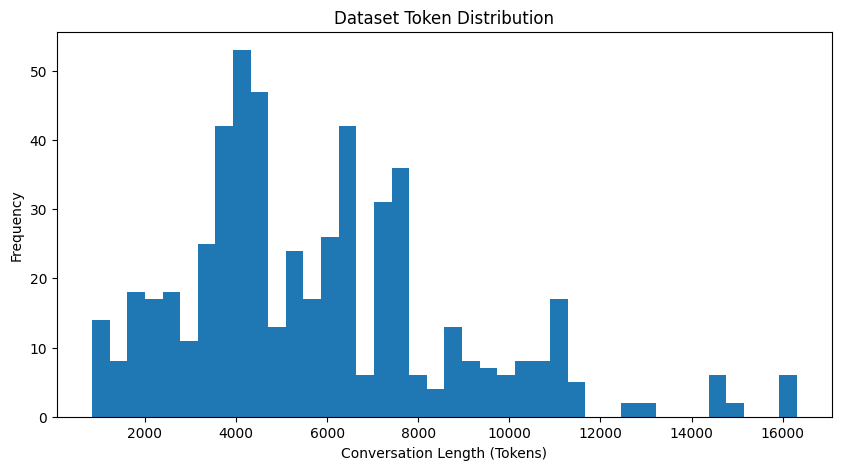

In [7]:
# ============================================================
# Dataset Statistics
# ============================================================

def count_tokens(example):
    text = ""

    for message in example["messages"]:
        text += message["content"] + "\n"

    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


print("=" * 70)
print("Computing Dataset Statistics...")
print("=" * 70)

token_lengths = []

for sample in tqdm(dataset):

    token_lengths.append(
        count_tokens(sample)
    )

token_lengths = np.array(token_lengths)

print()

print("=" * 70)

print(f"Total Samples        : {len(dataset)}")
print(f"Average Tokens       : {np.mean(token_lengths):.2f}")
print(f"Median Tokens        : {np.median(token_lengths):.2f}")
print(f"95th Percentile      : {np.percentile(token_lengths,95):.2f}")
print(f"99th Percentile      : {np.percentile(token_lengths,99):.2f}")
print(f"Maximum Tokens       : {np.max(token_lengths)}")
print(f"Minimum Tokens       : {np.min(token_lengths)}")

print("=" * 70)

plt.figure(figsize=(10,5))

plt.hist(
    token_lengths,
    bins=40,
)

plt.xlabel("Conversation Length (Tokens)")
plt.ylabel("Frequency")
plt.title("Dataset Token Distribution")

plt.show()

In [8]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

dataset = dataset.shuffle(seed=SEED)

# Split into Train and Remaining (Validation + Test)
train_test = dataset.train_test_split(
    test_size=(1 - TRAIN_SPLIT),
    seed=SEED,
)

train_dataset = train_test["train"]
remaining_dataset = train_test["test"]

# Split Remaining into Validation and Test
validation_ratio = VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)

validation_test = remaining_dataset.train_test_split(
    test_size=(1 - validation_ratio),
    seed=SEED,
)

validation_dataset = validation_test["train"]
test_dataset = validation_test["test"]

print("=" * 70)

print(f"Training Samples   : {len(train_dataset)} ({TRAIN_SPLIT*100:.0f}%)")
print(f"Validation Samples : {len(validation_dataset)} ({VAL_SPLIT*100:.0f}%)")
print(f"Test Samples       : {len(test_dataset)} ({TEST_SPLIT*100:.0f}%)")

print("=" * 70)

Training Samples   : 438 (80%)
Validation Samples : 55 (10%)
Test Samples       : 55 (10%)


In [9]:
# ============================================================
# Apply Chat Template
# ============================================================

def formatting_prompts_func(examples):

    conversations = examples["messages"]

    texts = [

        tokenizer.apply_chat_template(
            conversation,
            tokenize=False,
            add_generation_prompt=False,
        )

        for conversation in conversations

    ]

    return {

        "text": texts,

    }


train_dataset = train_dataset.map(
    formatting_prompts_func,
    batched=True,
)

validation_dataset = validation_dataset.map(
    formatting_prompts_func,
    batched=True,
)

test_dataset = test_dataset.map(
    formatting_prompts_func,
    batched=True,
)

print("=" * 70)
print("Chat Template Applied")
print("=" * 70)

print(train_dataset[0]["text"])

Map:   0%|          | 0/438 [00:00<?, ? examples/s]

Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Chat Template Applied
<｜begin▁of▁sentence｜>You are a Red Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective attack that is supported by the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing attack hypotheses before selecting the final attack.
• Base every conclusion only on the supplied information.

Do not assume undocumented behavior.

Do not invent vulnerabilities that are not supported by the code or architecture.

Do not rely on external knowledge about common softwa

In [10]:
training_args = SFTConfig(

    output_dir=OUTPUT_DIR,

    max_length=MAX_SEQ_LENGTH,

    dataset_text_field="text",

    packing=False,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=1,

    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=LEARNING_RATE,

    num_train_epochs=EPOCHS,

    warmup_ratio=WARMUP_RATIO,

    weight_decay=WEIGHT_DECAY,

    logging_steps=LOGGING_STEPS,

    logging_strategy="steps",

    eval_strategy="epoch",

    save_strategy="epoch",

    save_total_limit=SAVE_TOTAL_LIMIT,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",

    greater_is_better=False,

    bf16=torch.cuda.is_bf16_supported(),

    fp16=not torch.cuda.is_bf16_supported(),

    optim="adamw_8bit",

    lr_scheduler_type="cosine",
    
    dataloader_num_workers=0,

    dataloader_pin_memory=False,

    report_to="none",

    seed=SEED,

)

trainer = SFTTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=validation_dataset,

    processing_class=tokenizer,

)

trainer = train_on_responses_only(
    trainer,
    instruction_part="<｜User｜>",
    response_part="<｜Assistant｜>",
)
print("=" * 70)
print("Trainer Ready")
print("=" * 70)

print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(validation_dataset))
print("Test Samples       :", len(test_dataset))

print("=" * 70)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/438 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/55 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map:   0%|          | 0/438 [00:00<?, ? examples/s]

Filter:   0%|          | 0/438 [00:00<?, ? examples/s]

Unsloth: Removed 138 out of 438 samples from train_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


Map:   0%|          | 0/55 [00:00<?, ? examples/s]

Filter:   0%|          | 0/55 [00:00<?, ? examples/s]

Unsloth: Removed 20 out of 55 samples from eval_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.
Trainer Ready
Training Samples   : 438
Validation Samples : 55
Test Samples       : 55


In [11]:
messages = train_dataset[0]["messages"][:-1]

prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

print(prompt)

<｜begin▁of▁sentence｜>You are a Red Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective attack that is supported by the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing attack hypotheses before selecting the final attack.
• Base every conclusion only on the supplied information.

Do not assume undocumented behavior.

Do not invent vulnerabilities that are not supported by the code or architecture.

Do not rely on external knowledge about common software vulnerabilities whe

In [12]:
print("=" * 70)
print("Starting Training")
print("=" * 70)

start_time = time.time()

trainer_stats = trainer.train()

training_time = time.time() - start_time

print("=" * 70)
print("Training Complete")
print("=" * 70)

print(f"Training Time : {training_time/60:.2f} minutes")
print(f"Training Loss : {trainer_stats.training_loss:.6f}")

print("=" * 70)

Starting Training


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 5 | Total steps = 95
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 83,886,080 of 8,114,147,328 (1.03% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,2.649642,1.559273
2,1.289005,1.287191
3,0.762036,1.315552
4,0.403094,1.391438
5,0.250476,1.508845


Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-19/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-38/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-57/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-76/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-95/tokenizer_config.json.


Training Complete
Training Time : 359.09 minutes
Training Loss : 0.986399


In [13]:
# ============================================================
# Save Best Adapter
# ============================================================

BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_adapter")

trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

print("=" * 70)
print("Best Adapter Saved")
print("=" * 70)

print(BEST_MODEL_DIR)

Unsloth: Restored added_tokens_decoder metadata in ./outputs/best_adapter/tokenizer_config.json.


Best Adapter Saved
./outputs/best_adapter


In [14]:
FastLanguageModel.for_inference(model)

model.eval()

def generate_response(messages):

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(model.device)

    generation_kwargs = {
        "max_new_tokens": 1024,
        "do_sample": DO_SAMPLE,
        "use_cache": True,
        "pad_token_id": tokenizer.eos_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }

    if DO_SAMPLE:
        generation_kwargs["temperature"] = TEMPERATURE
        generation_kwargs["top_p"] = TOP_P

    with torch.inference_mode():

        outputs = model.generate(
            **inputs,
            **generation_kwargs,
        )

    prediction = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True,
    )

    return prediction.strip()


print("=" * 70)
print("Inference Ready")
print("=" * 70)

Inference Ready


In [15]:
validation_predictions = []

print("=" * 70)
print("Generating Validation Predictions")
print("=" * 70)

for sample in tqdm(validation_dataset):

    messages = sample["messages"][:-1]

    ground_truth = sample["messages"][-1]["content"]

    start_time = time.time()

    prediction = generate_response(messages)

    latency = time.time() - start_time

    validation_predictions.append({

        "messages": messages,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "latency": latency

    })

print("=" * 70)
print(f"Generated {len(validation_predictions)} Validation Predictions")
print("=" * 70)

Generating Validation Predictions


  0%|          | 0/55 [00:00<?, ?it/s]

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/t

Generated 55 Validation Predictions


In [16]:
# ============================================================
# Cell 16 - Display Validation Example
# ============================================================

example = validation_predictions[0]

print("\n" + "=" * 80)
print("VALIDATION SAMPLE")
print("=" * 80)

print("\nINPUT")

for message in example["messages"]:

    print(f"\n[{message['role'].upper()}]")

    print(message["content"][:1500])

print("\n" + "=" * 80)
print("GROUND TRUTH")
print("=" * 80)

print(example["ground_truth"])

print("\n" + "=" * 80)
print("MODEL PREDICTION")
print("=" * 80)

print(example["prediction"])

print("=" * 80)


VALIDATION SAMPLE

INPUT

[SYSTEM]
You are a Red Team cybersecurity analyst specializing in architectural security assessments of enterprise software systems.

Your objective is to identify the single most effective attack that is supported by the provided business context, architecture, workflow, trust boundaries, and source code.

Perform a structured architectural analysis before reaching a conclusion.

During your analysis:

• Identify the canonical security boundary of the application.
• Follow the end-to-end business workflow.
• Track how security-critical information is transformed between components.
• Distinguish architectural weaknesses from implementation details.
• Eliminate competing attack hypotheses before selecting the final attack.
• Base every conclusion only on the supplied information.

Do not assume undocumented behavior.

Do not invent vulnerabilities that are not supported by the code or architecture.

Do not rely on external knowledge about common software vuln

In [17]:
# ============================================================
# Cell 17 - Robust Evaluation Helper Functions
# Compatible with:
# - DeepSeek Coder
# - DeepSeek R1
# - Qwen
# - Llama
# ============================================================

import re

SECTION_HEADERS = [
    "correct attack:",
    "correct attack",
    "attack",
    "reasoning",
    "wrong_actions",
    "wrong_actions:",
    "wrong_action_reasoning",
    "wrong_action_reasoning:",
]


# ------------------------------------------------------------
# Clean generated text
# ------------------------------------------------------------
def clean_prediction(text):

    if text is None:
        return ""

    text = str(text)

    # --------------------------------------------------------
    # Remove thinking blocks
    # --------------------------------------------------------
    text = re.sub(
        r"<think>.*?</think>",
        "",
        text,
        flags=re.DOTALL | re.IGNORECASE,
    )

    # --------------------------------------------------------
    # Remove common chat template tokens
    # --------------------------------------------------------
    SPECIAL_TOKENS = [

        # DeepSeek
        "<｜begin▁of▁sentence｜>",
        "<｜end▁of▁sentence｜>",
        "<｜User｜>",
        "<｜Assistant｜>",

        # Older DeepSeek
        "<|EOT|>",

        # Llama / HF
        "<|begin_of_text|>",
        "<|end_of_text|>",
        "<|eot_id|>",
        "<|start_header_id|>",
        "<|end_header_id|>",

        # Generic
        "<s>",
        "</s>",
        "<bos>",
        "<eos>",
    ]

    for token in SPECIAL_TOKENS:
        text = text.replace(token, "")

    # --------------------------------------------------------
    # Remove any remaining special tokens
    # --------------------------------------------------------
    text = re.sub(
        r"<[^>\n]+>",
        "",
        text,
    )

    # --------------------------------------------------------
    # Remove duplicated chat template markers
    # --------------------------------------------------------
    text = re.sub(
        r"^\s*#{1,6}\s*(Instruction|Response)\s*:?\s*$",
        "",
        text,
        flags=re.MULTILINE | re.IGNORECASE,
    )

    # --------------------------------------------------------
    # Remove markdown formatting
    # --------------------------------------------------------
    text = re.sub(r"\*\*(.*?)\*\*", r"\1", text)
    text = re.sub(r"__(.*?)__", r"\1", text)
    text = re.sub(r"`(.*?)`", r"\1", text)

    # --------------------------------------------------------
    # Normalize line endings
    # --------------------------------------------------------
    text = text.replace("\r\n", "\n")
    text = text.replace("\r", "\n")

    # Collapse excessive blank lines
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


# ------------------------------------------------------------
# Normalize text
# ------------------------------------------------------------
def normalize(text):

    text = clean_prediction(text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()

# ------------------------------------------------------------
# Robust section extractor
# ------------------------------------------------------------
def _extract_section(text, section_name):

    text = clean_prediction(text)

    header_patterns = {
        "attack": r"attack",

        "reasoning": r"reasoning",

        "wrong_actions":
            r"wrong(?:[-_\s]+)?actions?(?:\(\s*s\s*\))?",

        "wrong_action_reasoning":
            r"wrong(?:[-_\s]+)?action(?:[-_\s]+)?reasonings?",
    }

    current_header = header_patterns.get(
        section_name,
        re.escape(section_name),
    )

    all_headers = "|".join(header_patterns.values())

    pattern = rf"""
        (?:^|\n)

        \s*

        (?:[#>*\-•]+\s*)?

        {current_header}

        \s*[:\-]?\s*

        (.*?)

        (?=
            \n
            \s*
            (?:[#>*\-•]+\s*)?
            (?:{all_headers})
            \s*[:\-]?

            |

            \Z
        )
    """

    match = re.search(
        pattern,
        text,
        flags=(
            re.IGNORECASE
            | re.MULTILINE
            | re.DOTALL
            | re.VERBOSE
        ),
    )

    if not match:
        return ""

    return match.group(1).strip()


# ------------------------------------------------------------
# Individual extractors
# ------------------------------------------------------------
def extract_attack(text):

    value = _extract_section(text, "attack")

    if not value:
        return ""

    for line in value.splitlines():

        line = line.strip()

        line = re.sub(
            r"^(\-|\*|•|\d+[\.\)])\s*",
            "",
            line,
        ).strip()

        if line:
            return line

    return ""


def extract_reasoning(text):

    return _extract_section(text, "reasoning")


def extract_wrong_actions(text):

    return _extract_section(text, "wrong_actions")


def extract_wrong_action_reasoning(text):

    return _extract_section(text, "wrong_action_reasoning")


# ------------------------------------------------------------
# Parse wrong actions
# ------------------------------------------------------------
def parse_wrong_actions(text):

    block = extract_wrong_actions(text)

    actions = []

    for line in block.splitlines():

        line = line.strip()

        line = re.sub(
            r"^(\-|\*|•|\d+[\.\)])\s*",
            "",
            line,
        )

        if line:
            actions.append(normalize(line))

    return set(actions)


# ------------------------------------------------------------
# Structure validation
# ------------------------------------------------------------
def structure_correct(text):

    return all([
        extract_attack(text),
        extract_reasoning(text),
        extract_wrong_actions(text),
        extract_wrong_action_reasoning(text),
    ])


print("=" * 70)
print("Robust Evaluation Helper Functions Ready")
print("=" * 70)

Robust Evaluation Helper Functions Ready


In [18]:
# ============================================================
# Cell 18 - Unified Evaluation Function (Attack Model)
# DeepSeek Coder Version
# ============================================================

embedding_model = SentenceTransformer(
    "sentence-transformers/all-mpnet-base-v2"
)


def evaluate_predictions(predictions):

    attack_gt = []
    attack_pred = []

    reasoning_gt = []
    reasoning_pred = []

    wrong_reasoning_gt = []
    wrong_reasoning_pred = []

    wrong_action_scores = []

    structure_scores = []

    exact_matches = []

    latencies = []

    detailed_rows = []

    # ======================================================
    # Parse Predictions
    # ======================================================

    for sample in tqdm(predictions):

        gt = sample["ground_truth"]
        pred = sample["prediction"]

        # -----------------------------
        # Attack
        # -----------------------------

        gt_attack = normalize(extract_attack(gt))
        pred_attack = normalize(extract_attack(pred))

        attack_gt.append(gt_attack)
        attack_pred.append(pred_attack)

        # -----------------------------
        # Reasoning
        # -----------------------------

        gt_reasoning = clean_prediction(
            extract_reasoning(gt)
        )

        pred_reasoning = clean_prediction(
            extract_reasoning(pred)
        )

        if not pred_reasoning:
            pred_reasoning = "<EMPTY>"

        reasoning_gt.append(gt_reasoning)
        reasoning_pred.append(pred_reasoning)

        # -----------------------------
        # Wrong Action Reasoning
        # -----------------------------

        gt_wrong_reasoning = clean_prediction(
            extract_wrong_action_reasoning(gt)
        )

        pred_wrong_reasoning = clean_prediction(
            extract_wrong_action_reasoning(pred)
        )

        if not pred_wrong_reasoning:
            pred_wrong_reasoning = "<EMPTY>"

        wrong_reasoning_gt.append(gt_wrong_reasoning)
        wrong_reasoning_pred.append(pred_wrong_reasoning)

        # -----------------------------
        # Wrong Actions
        # -----------------------------

        gt_actions = parse_wrong_actions(gt)
        pred_actions = parse_wrong_actions(pred)

        wrong_action_scores.append(
            int(gt_actions == pred_actions)
        )

        # -----------------------------
        # Structure / Exact Match
        # -----------------------------

        structure = int(
            structure_correct(pred)
        )

        exact = int(
            normalize(gt) == normalize(pred)
        )

        structure_scores.append(structure)
        exact_matches.append(exact)

        latencies.append(
            sample.get("latency", np.nan)
        )

        detailed_rows.append({

            "ground_truth_attack": gt_attack,
            "predicted_attack": pred_attack,
            "attack_correct": gt_attack == pred_attack,

            "ground_truth_reasoning": gt_reasoning,
            "predicted_reasoning": pred_reasoning,

            "ground_truth_wrong_actions": sorted(gt_actions),
            "predicted_wrong_actions": sorted(pred_actions),
            "wrong_actions_correct": gt_actions == pred_actions,

            "ground_truth_wrong_action_reasoning":
                gt_wrong_reasoning,

            "predicted_wrong_action_reasoning":
                pred_wrong_reasoning,

            "exact_match": bool(exact),

            "structure_score": structure,

        })

    # ======================================================
    # Semantic Similarity (Reasoning)
    # ======================================================

    if reasoning_gt:

        gt_reasoning_embeddings = embedding_model.encode(
            reasoning_gt,
            batch_size=32,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        pred_reasoning_embeddings = embedding_model.encode(
            reasoning_pred,
            batch_size=32,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        reasoning_similarity = float(

            util.cos_sim(
                pred_reasoning_embeddings,
                gt_reasoning_embeddings,
            ).diagonal().mean().item()

        )

    else:

        reasoning_similarity = 0.0

    # ======================================================
    # Semantic Similarity (Wrong Action Reasoning)
    # ======================================================

    if wrong_reasoning_gt:

        gt_wrong_embeddings = embedding_model.encode(
            wrong_reasoning_gt,
            batch_size=32,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        pred_wrong_embeddings = embedding_model.encode(
            wrong_reasoning_pred,
            batch_size=32,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        wrong_reasoning_similarity = float(

            util.cos_sim(
                pred_wrong_embeddings,
                gt_wrong_embeddings,
            ).diagonal().mean().item()

        )

    else:

        wrong_reasoning_similarity = 0.0

    # ======================================================
    # Final Metrics
    # ======================================================

    metrics = {

        "attack_accuracy": float(
            accuracy_score(
                attack_gt,
                attack_pred,
            )
        ) if attack_gt else 0.0,

        "reasoning_similarity":
            reasoning_similarity,

        "wrong_actions_accuracy": float(
            np.mean(wrong_action_scores)
        ) if wrong_action_scores else 0.0,

        "wrong_action_reasoning_similarity":
            wrong_reasoning_similarity,

        "exact_match": float(
            np.mean(exact_matches)
        ) if exact_matches else 0.0,

        "structure_score": float(
            np.mean(structure_scores)
        ) if structure_scores else 0.0,

        "average_latency": float(
            np.nanmean(latencies)
        ) if latencies else 0.0,

    }

    results_df = pd.DataFrame(detailed_rows)

    return metrics, results_df

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [19]:
# ============================================================
# Cell 19 - Evaluate Validation Set
# ============================================================

validation_metrics, validation_results = evaluate_predictions(validation_predictions)

print("=" * 70)
print("VALIDATION REPORT")
print("=" * 70)

for metric, value in validation_metrics.items():

    if isinstance(value, float):

        print(f"{metric:<25}: {value:.4f}")

    else:

        print(f"{metric:<25}: {value}")

print("=" * 70)

display(validation_results.head())

  0%|          | 0/55 [00:00<?, ?it/s]

VALIDATION REPORT
attack_accuracy          : 0.0000
reasoning_similarity     : -0.0391
wrong_actions_accuracy   : 0.2545
wrong_action_reasoning_similarity: 0.0516
exact_match              : 0.0000
structure_score          : 0.0000
average_latency          : 53.0010


,ground_truth_attack,predicted_attack,attack_correct,ground_truth_reasoning,predicted_reasoning,ground_truth_wrong_actions,predicted_wrong_actions,wrong_actions_correct,ground_truth_wrong_action_reasoning,predicted_wrong_action_reasoning,exact_match,structure_score
0,symlink_extraction_traversal,symlink_extraction_traversalreasoning:1.thearc...,False,1. UploadHandler.go accepts evidence archives ...,<EMPTY>,"[command_injection, jwt_forgery, sql_injection]",[],False,sql_injection: No attacker-controlled database...,<EMPTY>,False,0
1,workspace_session_attachment_drift,session_lease_drift_abusereasoning:1.sessionve...,False,1. SessionVerifier.VerifyLease confirms a sess...,<EMPTY>,"[replay_stale_worker_session_token, tool_chann...",[],False,tool_channel_injection: normalize_channels in ...,<EMPTY>,False,0
2,secret_rotation_epoch_drift,secret_rotation_epoch_driftreasoning:1.approve...,False,1. ApprovedSecretRotation.swift defines the ca...,<EMPTY>,"[forge_approval_signature, sql_injection_rotat...",[],False,forge_approval_signature: RotationApprovalServ...,<EMPTY>,False,0
3,jwt_forgery,jwt_forgeryreasoning:1.theattackerobtainsjwt_s...,False,The login endpoint issues tokens but checking ...,<EMPTY>,[],[],True,,<EMPTY>,False,0
4,stale_approval_state_abuse,stale_approval_state_abusereasoning:1.approval...,False,1. The intended security boundary is current a...,<EMPTY>,"[controller_authorization_failure, nats_messag...",[],False,nats_message_replay:\nThe vulnerability exists...,<EMPTY>,False,0


In [20]:
# ============================================================
# Cell 20 - Generate Test Predictions
# ============================================================

test_predictions = []

print("=" * 70)
print("Generating Test Predictions")
print("=" * 70)

for sample in tqdm(test_dataset):

    messages = sample["messages"][:-1]

    ground_truth = sample["messages"][-1]["content"]

    start_time = time.time()

    prediction = generate_response(messages)

    latency = time.time() - start_time

    test_predictions.append({

        "messages": messages,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "latency": latency
    })

print("=" * 70)
print(f"Generated {len(test_predictions)} Test Predictions")
print("=" * 70)

example = test_predictions[0]

print("\nTEST SAMPLE")
print("=" * 70)

print("\nGROUND TRUTH\n")
print(example["ground_truth"])

print("\nMODEL PREDICTION\n")
print(example["prediction"])

print("\nLatency :", f"{example['latency']:.3f} sec")

print("=" * 70)

Generating Test Predictions


  0%|          | 0/55 [00:00<?, ?it/s]

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/t

Generated 55 Test Predictions

TEST SAMPLE

GROUND TRUTH

Attack: federated_identity_mapping_abuse

Reasoning:
FederationProfile.projectRoles flow through IdentityMappingService, UserProvisioningService, ProvisioningWorker, and RedisRoleCache before reaching RolePolicy authorization decisions. Project role assignments are never validated before becoming permissions.

wrong_actions:
- path_traversal
- stored_xss
- malicious_file_upload

wrong_action_reasoning:
path_traversal: No filesystem access or path manipulation is involved.

stored_xss: The attack does not rely on rendering attacker-controlled content in a browser.

malicious_file_upload: No file upload workflow participates in the privilege escalation path.

MODEL PREDICTION

Attack:federated_identity_mapping_abuseReasoning:1.FederationController.ktreceivesfederatedloginrequestsandcallsIdentityMappingService.mapFederatedIdentity().2.IdentityMappingService.ktvalidatesfederationstate,providertrust,andorganizationrolesbeforeconstruc

In [21]:
# ============================================================
# Cell 21 - Evaluate Test Set
# ============================================================

test_metrics, test_results = evaluate_predictions(test_predictions)

print("=" * 70)
print("TEST REPORT")
print("=" * 70)

for metric, value in test_metrics.items():

    if isinstance(value, float):

        print(f"{metric:<25}: {value:.4f}")

    else:

        print(f"{metric:<25}: {value}")

print("=" * 70)

display(test_results.head())

  0%|          | 0/55 [00:00<?, ?it/s]

TEST REPORT
attack_accuracy          : 0.0000
reasoning_similarity     : -0.0223
wrong_actions_accuracy   : 0.3091
wrong_action_reasoning_similarity: 0.0777
exact_match              : 0.0000
structure_score          : 0.0000
average_latency          : 49.2065


,ground_truth_attack,predicted_attack,attack_correct,ground_truth_reasoning,predicted_reasoning,ground_truth_wrong_actions,predicted_wrong_actions,wrong_actions_correct,ground_truth_wrong_action_reasoning,predicted_wrong_action_reasoning,exact_match,structure_score
0,federated_identity_mapping_abuse,federated_identity_mapping_abusereasoning:1.fe...,False,FederationProfile.projectRoles flow through Id...,<EMPTY>,"[malicious_file_upload, path_traversal, stored...",[],False,path_traversal: No filesystem access or path m...,<EMPTY>,False,0
1,distributed_secret_lease_synchronization_corru...,secret_lease_continuity_abusereasoning:1.secre...,False,1. SecretAccessRequest.validate() checks that ...,<EMPTY>,"[cross_rotation_lease_drift, forge_approval_si...",[],False,manipulate_secret_access_request_labels: Secre...,<EMPTY>,False,0
2,event_replay_authorization_collapse,stale_entitlement_cache_abusereasoning:1.reser...,False,1. Source: ReservationRequest.swift. This is u...,<EMPTY>,[],[],True,,<EMPTY>,False,0
3,index_authorization_drift_abuse,index_authorization_drift_abusereasoning:1.doc...,False,1. Trust Boundary 1 - Document Authorization: ...,<EMPTY>,[],[],True,,<EMPTY>,False,0
4,delegated capability continuity collapse,capabilityscopepropagationabusereasoning:1.the...,False,1. The platform's stated security boundary is ...,<EMPTY>,"[downgrade policy resolution to an older, more...",[],False,Forge an approval signature to mint an unappro...,<EMPTY>,False,0


In [22]:
# ============================================================
# Cell 22 - Validation vs Test Comparison (Attack Model)
# ============================================================

comparison = pd.DataFrame({

    "Metric": [

        "Attack Accuracy",
        "Reasoning Similarity",
        "Wrong Actions Accuracy",
        "Wrong Action Reasoning Similarity",
        "Exact Match",
        "Structure Score",
        "Average Latency",

    ],

    "Validation": [

        validation_metrics["attack_accuracy"],
        validation_metrics["reasoning_similarity"],
        validation_metrics["wrong_actions_accuracy"],
        validation_metrics["wrong_action_reasoning_similarity"],
        validation_metrics["exact_match"],
        validation_metrics["structure_score"],
        validation_metrics["average_latency"],

    ],

    "Test": [

        test_metrics["attack_accuracy"],
        test_metrics["reasoning_similarity"],
        test_metrics["wrong_actions_accuracy"],
        test_metrics["wrong_action_reasoning_similarity"],
        test_metrics["exact_match"],
        test_metrics["structure_score"],
        test_metrics["average_latency"],

    ],

})

display(comparison)

print("=" * 70)
print("Attack Model Comparison Complete")
print("=" * 70)

,Metric,Validation,Test
0,Attack Accuracy,0.000000,0.000000
1,Reasoning Similarity,-0.039059,-0.022307
2,Wrong Actions Accuracy,0.254545,0.309091
3,Wrong Action Reasoning Similarity,0.051639,0.077740
4,Exact Match,0.000000,0.000000
5,Structure Score,0.000000,0.000000
6,Average Latency,53.001011,49.206528


Attack Model Comparison Complete


In [23]:
# ============================================================
# Cell 23 - Save Evaluation Results
# ============================================================

RESULTS_DIR = "./results"

os.makedirs(RESULTS_DIR,exist_ok=True)

validation_results.to_csv(os.path.join(RESULTS_DIR,"validation_results.csv"),index=False)

test_results.to_csv(os.path.join(RESULTS_DIR,"test_results.csv"),index=False)

metrics = {
    "training_loss": float(trainer_stats.training_loss),
    "validation": validation_metrics,
    "test": test_metrics
}

with open(

    os.path.join(RESULTS_DIR,"metrics.json"),"w") as f:

    json.dump(
        metrics,
        f,
        indent=4,
    )

print("=" * 70)
print("Results Saved Successfully")
print("=" * 70)

print(RESULTS_DIR)

Results Saved Successfully
./results


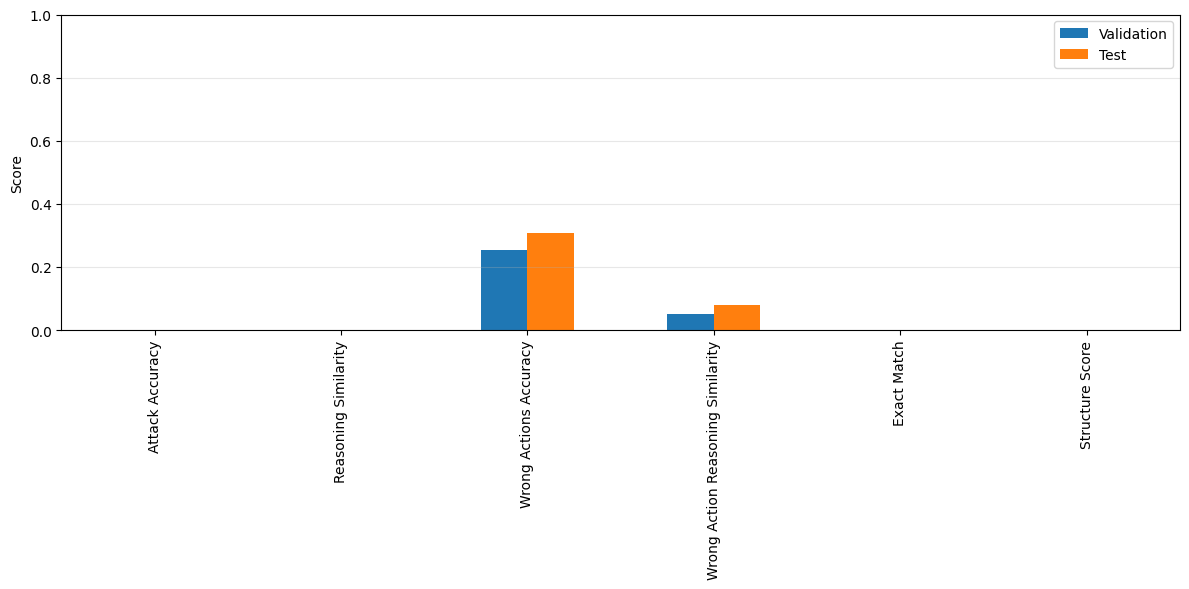

In [24]:
# ============================================================
# Cell 24 - Evaluation Visualizations (Attack Model)
# ============================================================

metrics_df = pd.DataFrame({

    "Metric": [
        "Attack Accuracy",
        "Reasoning Similarity",
        "Wrong Actions Accuracy",
        "Wrong Action Reasoning Similarity",
        "Exact Match",
        "Structure Score",
    ],

    "Validation": [
        validation_metrics["attack_accuracy"],
        validation_metrics["reasoning_similarity"],
        validation_metrics["wrong_actions_accuracy"],
        validation_metrics["wrong_action_reasoning_similarity"],
        validation_metrics["exact_match"],
        validation_metrics["structure_score"],
    ],

    "Test": [
        test_metrics["attack_accuracy"],
        test_metrics["reasoning_similarity"],
        test_metrics["wrong_actions_accuracy"],
        test_metrics["wrong_action_reasoning_similarity"],
        test_metrics["exact_match"],
        test_metrics["structure_score"],
    ]

})

metrics_df.set_index("Metric").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="")
plt.tight_layout()
plt.show()